In [ ]:
import os
os.environ['CURRENT_NOTEBOOK_NAME'] = 'final-dataset'
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from utils import *


[Auto-Save] IPython hook setup failed: module 'IPython.core.display' has no attribute 'display'


/Volumes/HP_P900/Users/tungnguyen/Programming/Chest-Medical-Image-Fusion-for-Multimodal-Clinical-Analysis/data/00-examine-data
/Volumes/HP_P900/Users/tungnguyen/Programming/Chest-Medical-Image-Fusion-for-Multimodal-Clinical-Analysis
/Volumes/HP_P900/Users/tungnguyen/Programming/Chest-Medical-Image-Fusion-for-Multimodal-Clinical-Analysis/data
(376817, 53)
[Auto-Save] Saved DataFrame result to /Volumes/HP_P900/Users/tungnguyen/Programming/Chest-Medical-Image-Fusion-for-Multimodal-Clinical-Analysis/output/eda/final-dataset/result_01_df.txt
train val 0
test train 0
test val 0
[Auto-Save] Saved DataFrame result to /Volumes/HP_P900/Users/tungnguyen/Programming/Chest-Medical-Image-Fusion-for-Multimodal-Clinical-Analysis/output/eda/final-dataset/result_02_df.txt
                     label  positive  total  prevalence
           Support Devices     89059 264634    0.336536
              Lung Opacity     79877 264634    0.301840
              Cardiomegaly     76847 264634    0.290390
          P

In [2]:
root_dir, data_dir = get_notebook_paths()
MIMIC_CXR_JPG_DIR = data_dir / "MIMIC-CXR-JPG"
DATA_CAMCHEX = data_dir / "data-camchex"

print(Path.cwd())
print(root_dir)
print(data_dir)


In [3]:
train = pd.read_csv(DATA_CAMCHEX / "03_mimic_train.csv")
test = pd.read_csv(DATA_CAMCHEX / "03_mimic_test.csv")
dev = pd.read_csv(DATA_CAMCHEX / "03_mimic_development.csv")

train["split"] = "train"
test["split"] = "test"
dev["split"] = "dev"

data = pd.concat([train, test, dev], axis=0).reset_index(drop=True)
print(data.shape)
data.head()

del train, test, dev


/var/folders/wj/8406k4zs34b1rtmbdltdknl00000gp/T/ipykernel_25873/1158349764.py:1: DtypeWarning: Columns (13,15,16,17,18,19,20) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv(DATA_CAMCHEX / "03_mimic_train.csv")


In [4]:
LABEL_COLS = [
    "Atelectasis", "Calcification of the Aorta", "Cardiomegaly", "Consolidation",
    "Edema", "Emphysema", "Enlarged Cardiomediastinum", "Fibrosis", "Fracture",
    "Hernia", "Infiltration", "Lung Lesion", "Lung Opacity", "Mass", "No Finding",
    "Nodule", "Pleural Effusion", "Pleural Other", "Pleural Thickening",
    "Pneumomediastinum", "Pneumonia", "Pneumoperitoneum", "Pneumothorax",
    "Subcutaneous Emphysema", "Support Devices", "Tortuous Aorta",
]

VITAL_COLS = ["temperature", "heartrate", "resprate", "o2sat", "sbp", "dbp"]


In [5]:
# Split summary

split_summary = (
    data.groupby("split")
    .agg(
        rows=("dicom_id", "count"),
        patients=("subject_id", "nunique"),
        studies=("study_id", "nunique"),
        images=("dicom_id", "nunique"),
    )
    .reset_index()
)

split_summary


,split,rows,patients,studies,images
0,dev,36737,6534,22268,36737
1,test,75446,13068,45462,75446
2,train,264634,45746,159928,264634


In [6]:
# Check patient overlap

patients = {
    split: set(data.loc[data["split"] == split, "subject_id"])
    for split in ["train", "val", "test"]
}

for a in ["train", "val", "test"]:
    for b in ["train", "val", "test"]:
        if a < b:
            overlap = patients[a] & patients[b]
            print(a, b, len(overlap))


In [7]:
# Lablel distribution

label_prev = []

for split, df in data.groupby("split"):
    for label in LABEL_COLS:
        n_pos = df[label].sum()
        n_total = len(df)
        label_prev.append({
            "split": split,
            "label": label,
            "positive": int(n_pos),
            "total": int(n_total),
            "prevalence": n_pos / n_total,
        })

label_prev = pd.DataFrame(label_prev)

label_prev.sort_values(["split", "prevalence"], ascending=[True, False])


,split,label,positive,total,prevalence
24,dev,Support Devices,12519,36737,0.340774
12,dev,Lung Opacity,11362,36737,0.309279
2,dev,Cardiomegaly,10464,36737,0.284835
16,dev,Pleural Effusion,9580,36737,0.260773
0,dev,Atelectasis,9134,36737,0.248632
...,...,...,...,...,...
75,train,Subcutaneous Emphysema,2453,264634,0.009269
59,train,Fibrosis,1158,264634,0.004376
71,train,Pneumomediastinum,786,264634,0.002970
69,train,Pleural Other,675,264634,0.002551


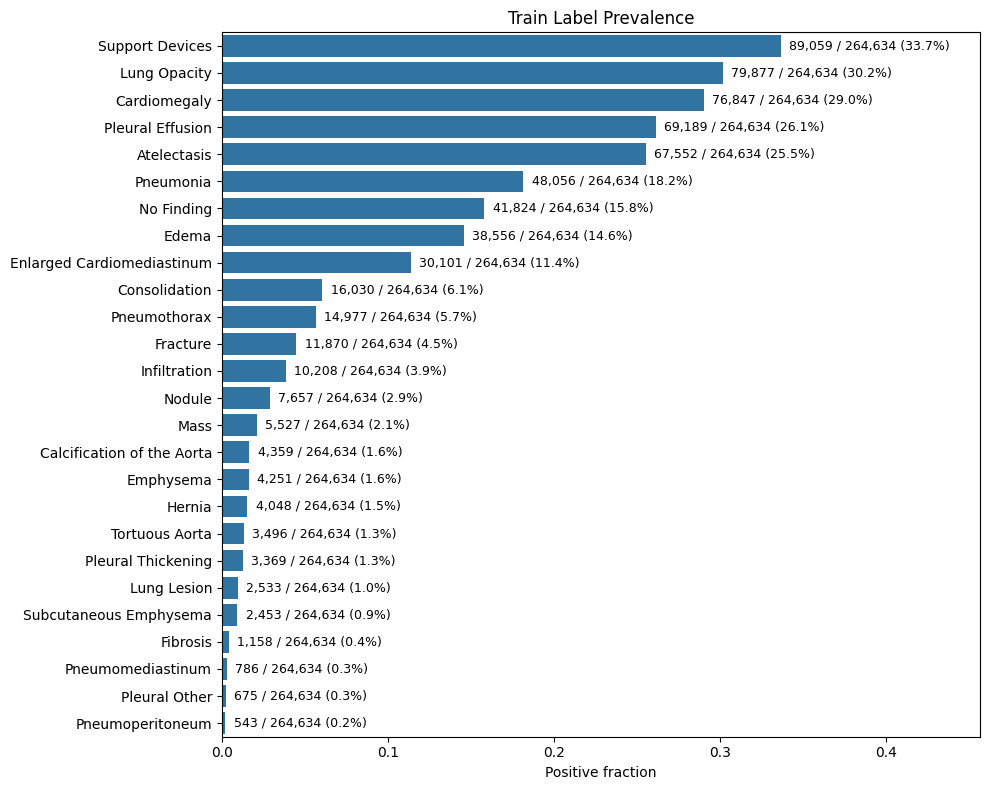

In [8]:
# Plot label imbalance

train_prev = (
    label_prev[label_prev["split"] == "train"]
    .sort_values("prevalence", ascending=False)
    .reset_index(drop=True)
)

# Print counts
print(train_prev[["label", "positive", "total", "prevalence"]].to_string(index=False))

# Plot prevalence with counts
plt.figure(figsize=(10, 8))
ax = sns.barplot(data=train_prev, x="prevalence", y="label")

plt.title("Train Label Prevalence")
plt.xlabel("Positive fraction")
plt.ylabel("")

for i, row in train_prev.iterrows():
    ax.text(
        row["prevalence"] + 0.005,
        i,
        f'{int(row["positive"]):,} / {int(row["total"]):,} ({row["prevalence"]:.1%})',
        va="center",
        fontsize=9,
    )

ax.set_xlim(0, min(1.0, train_prev["prevalence"].max() + 0.12))

plt.tight_layout()
plt.show()


In [9]:
# Check missing

cols_to_check = [
    "clinical_indication",
    "temperature", "heartrate", "resprate", "o2sat", "sbp", "dbp",
    "gender", "ViewPosition", "path",
]

missing = []

for split, df in data.groupby("split"):
    for col in cols_to_check:
        missing.append({
            "split": split,
            "column": col,
            "missing": df[col].isna().sum(),
            "total": len(df),
            "missing_rate": df[col].isna().mean(),
        })

missing = pd.DataFrame(missing)
missing.sort_values(["split", "missing_rate"], ascending=[True, False])


,split,column,missing,total,missing_rate
1,dev,temperature,6068,36737,0.165174
3,dev,resprate,5548,36737,0.151019
4,dev,o2sat,5391,36737,0.146746
6,dev,dbp,5331,36737,0.145113
5,dev,sbp,5204,36737,0.141656
2,dev,heartrate,5110,36737,0.139097
7,dev,gender,1937,36737,0.052726
8,dev,ViewPosition,1494,36737,0.040667
0,dev,clinical_indication,723,36737,0.019680
9,dev,path,0,36737,0.000000


In [10]:
# View distribution

view_dist = (
    data.groupby(["split", "ViewPosition"])
    .size()
    .reset_index(name="count")
    .sort_values(["split", "count"], ascending=[True, False])
)

view_dist


,split,ViewPosition,count
0,dev,AP,14459
4,dev,PA,9299
1,dev,LATERAL,8235
2,dev,LL,3248
3,dev,LPO,1
5,dev,XTABLE LATERAL,1
6,test,AP,29361
11,test,PA,19288
9,test,LATERAL,16584
10,test,LL,6985


In [11]:
# Label re appearance

label_matrix = data[LABEL_COLS].astype(int)

cooccurrence = label_matrix.T @ label_matrix
cooccurrence


,Atelectasis,Calcification of the Aorta,Cardiomegaly,Consolidation,Edema,Emphysema,Enlarged Cardiomediastinum,Fibrosis,Fracture,Hernia,...,Pleural Effusion,Pleural Other,Pleural Thickening,Pneumomediastinum,Pneumonia,Pneumoperitoneum,Pneumothorax,Subcutaneous Emphysema,Support Devices,Tortuous Aorta
Atelectasis,96245,1539,35135,6450,17447,1376,11616,291,4621,1892,...,46255,161,1352,299,16001,357,7760,1499,45535,1219
Calcification of the Aorta,1539,6256,2735,292,1185,232,750,28,472,197,...,1573,22,58,1,1013,4,84,15,1606,217
Cardiomegaly,35135,2735,109218,7131,29840,1386,11509,534,4699,2094,...,39576,261,1411,186,19361,160,4436,547,43558,2705
Consolidation,6450,292,7131,22754,5424,549,2151,128,845,281,...,11423,46,300,60,7513,80,1292,187,10711,173
Edema,17447,1185,29840,5424,55111,897,5540,316,1787,736,...,28913,70,511,55,10308,91,1848,272,26632,566
Emphysema,1376,232,1386,549,897,5878,868,158,479,148,...,1609,79,213,85,1447,5,544,207,1601,101
Enlarged Cardiomediastinum,11616,750,11509,2151,5540,868,42937,257,2065,811,...,10867,153,690,1061,7320,135,2627,848,13244,631
Fibrosis,291,28,534,128,316,158,257,1758,66,23,...,417,11,68,12,443,0,74,17,499,26
Fracture,4621,472,4699,845,1787,479,2065,66,16973,423,...,4232,85,524,83,2333,11,1753,384,5127,344
Hernia,1892,197,2094,281,736,148,811,23,423,5835,...,1560,26,68,30,981,27,249,76,1501,116


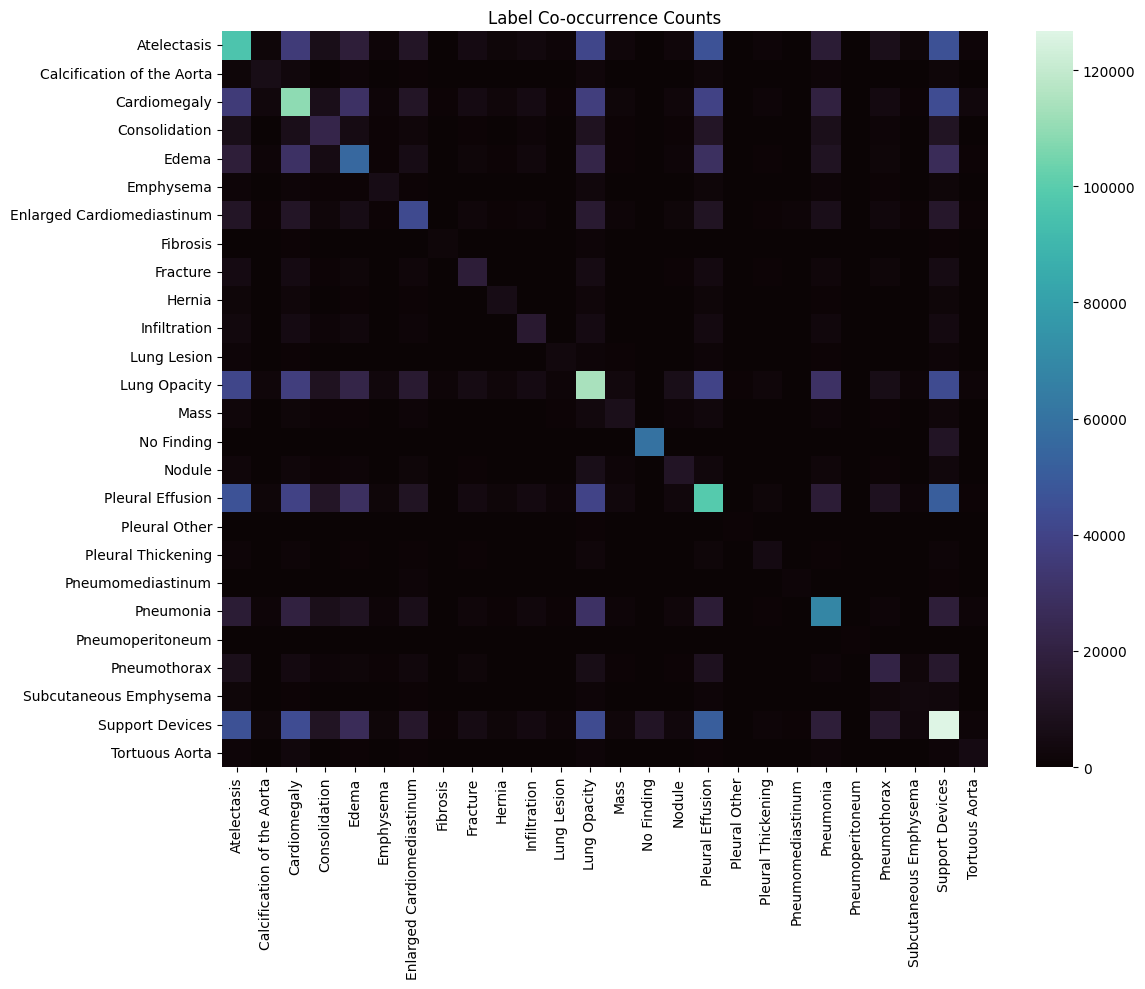

In [12]:
plt.figure(figsize=(12, 10))
sns.heatmap(cooccurrence, cmap="mako")
plt.title("Label Co-occurrence Counts")
plt.tight_layout()
plt.show()


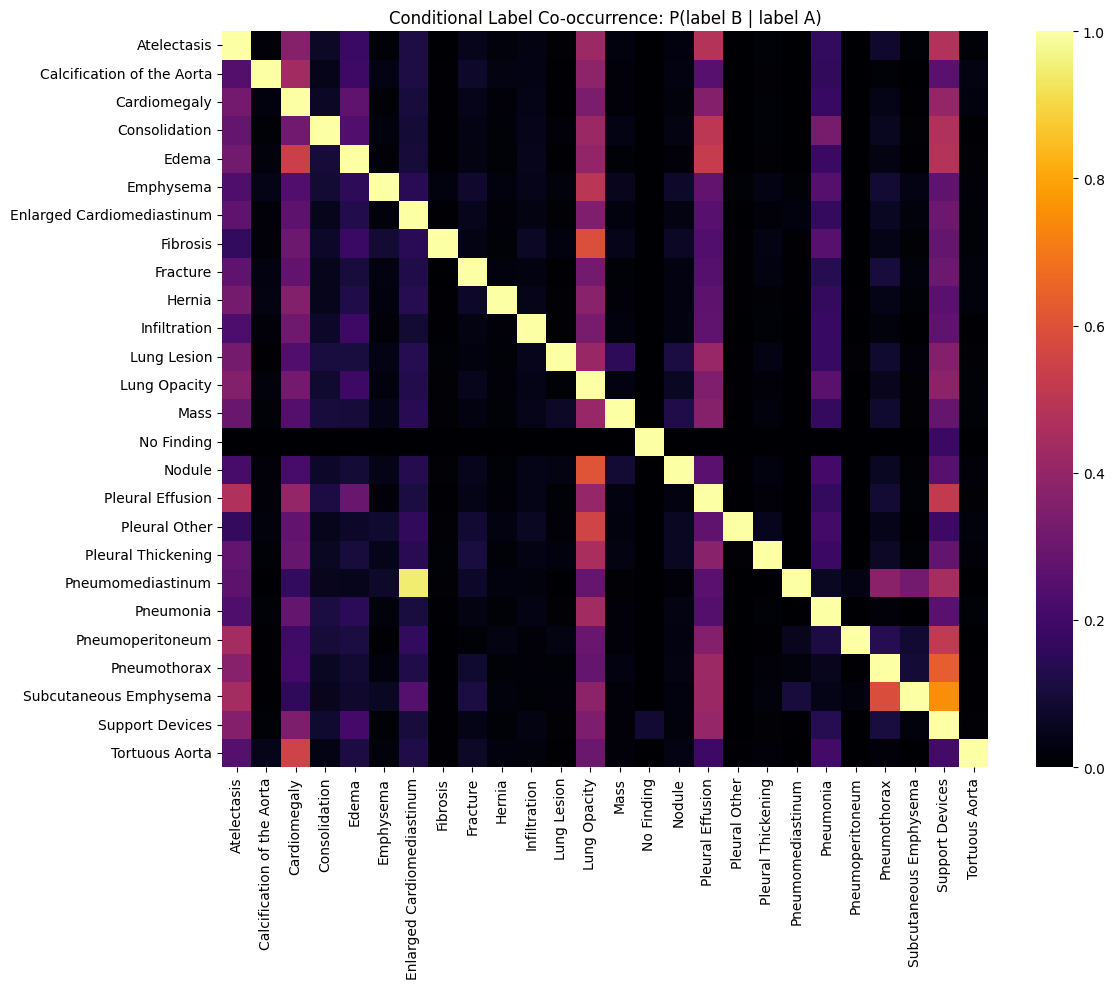

In [13]:
# Conditional co-occurrence

conditional = cooccurrence.div(np.diag(cooccurrence), axis=0)

plt.figure(figsize=(12, 10))
sns.heatmap(conditional, cmap="inferno", vmin=0, vmax=1)
plt.title("Conditional Label Co-occurrence: P(label B | label A)")
plt.tight_layout()
plt.show()


In [14]:
# Vital by disease label

vital_summary = []

for label in LABEL_COLS:
    pos = data[data[label] == 1]
    neg = data[data[label] == 0]

    for vital in VITAL_COLS:
        vital_summary.append({
            "label": label,
            "vital": vital,
            "positive_mean": pos[vital].mean(),
            "negative_mean": neg[vital].mean(),
            "difference": pos[vital].mean() - neg[vital].mean(),
            "positive_n": pos[vital].notna().sum(),
            "negative_n": neg[vital].notna().sum(),
        })

vital_summary = pd.DataFrame(vital_summary)

vital_summary.sort_values("difference", key=abs, ascending=False).head(30)


,label,vital,positive_mean,negative_mean,difference,positive_n,negative_n
59,Hernia,dbp,101.569951,77.449917,24.120034,5318,319137
130,Pneumoperitoneum,sbp,127.532847,133.765142,-6.232295,685,324606
10,Calcification of the Aorta,sbp,139.555179,133.650198,5.904981,5609,319682
131,Pneumoperitoneum,dbp,72.064234,77.857489,-5.793255,685,323770
148,Support Devices,sbp,129.785488,135.474337,-5.688849,98483,226808
7,Calcification of the Aorta,heartrate,81.467295,86.863752,-5.396457,5626,320339
58,Hernia,sbp,139.051494,133.663889,5.387605,5321,319970
107,Pleural Other,dbp,72.626604,77.859079,-5.232474,857,323598
22,Consolidation,sbp,128.870850,134.043713,-5.172863,18343,306948
35,Emphysema,dbp,72.824096,77.925253,-5.101157,5088,319367


In [15]:
# Report / Text length

data["clinical_indication_words"] = (
    data["clinical_indication"]
    .fillna("")
    .astype(str)
    .str.split()
    .str.len()
)

text_summary = (
    data.groupby("split")["clinical_indication_words"]
    .describe()
)

text_summary


,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
dev,36737.0,12.177859,10.058190,0.0,7.0,10.0,15.0,222.0
test,75446.0,12.054330,9.899612,0.0,7.0,10.0,15.0,275.0
train,264634.0,12.262287,10.005628,0.0,7.0,10.0,15.0,268.0


In [16]:
# Multilable density

data["num_positive_labels"] = data[LABEL_COLS].sum(axis=1)

data.groupby("split")["num_positive_labels"].describe()


,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
dev,36737.0,2.397746,1.501634,0.0,1.0,2.0,3.0,10.0
test,75446.0,2.401930,1.493236,0.0,1.0,2.0,3.0,10.0
train,264634.0,2.399544,1.498477,0.0,1.0,2.0,3.0,11.0


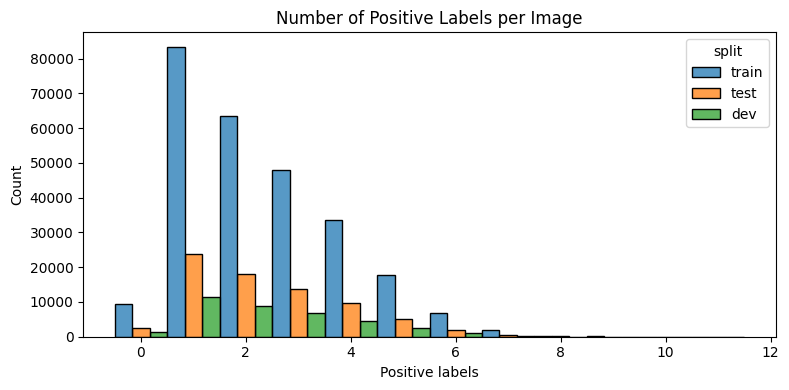

In [17]:
plt.figure(figsize=(8, 4))
sns.histplot(data=data, x="num_positive_labels", hue="split", discrete=True, multiple="dodge")
plt.title("Number of Positive Labels per Image")
plt.xlabel("Positive labels")
plt.tight_layout()
plt.show()
